# CTD Profiles After 15 August 2026

This notebook plots water temperature and chlorophyll-a concentration against depth for CTD profiles acquired after 15 August 2026. Each profile is colored by its acquisition date, with the same date color scale used in both panels.

The source variables are `depth` (m), `Temp` (deg C), and `Chl_A` (micrograms per litre). Quality flags are applied using `depth_qual`, `Temp_qual`, and `Chl_A_qual` where available.

In [10]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from netCDF4 import Dataset, num2date

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "léxplorectdprofiles_datalakesdownload"
GRAPHS_DIR = PROJECT_DIR / "graphs"
CUTOFF = pd.Timestamp("2026-08-20", tz="UTC")
CONDUCTIVITY_ALPHA_PER_C = 0.02
REFERENCE_TEMPERATURE_C = 25.0
OUTPUT_PNG = GRAPHS_DIR / "ctd_temperature_chlorophyll_profiles_from_2026_08_20.png"
GRAPHS_DIR.mkdir(exist_ok=True)
assert DATA_DIR.is_dir(), f"Missing CTD directory: {DATA_DIR}"

## Weather Since 20 August 2026

Daily air temperature, solar irradiance, and wind speed are shown before the CTD profiles. Wind-direction arrows are placed above the wind-speed panel and use the dominant 16-sector direction for each day. The arrow orientation follows meteorological convention: north is up and east is right.

In [11]:
METEO_DIR = PROJECT_DIR / "data" / "léxploremeteostation_datalakesdownload (2)"
WEATHER_PNG = GRAPHS_DIR / "weather_since_2026_08_20.png"
meteo_paths = sorted(METEO_DIR.glob("*.nc"))
assert meteo_paths, f"No meteorological NetCDF files found in {METEO_DIR}"

meteo_frames = []
for path in meteo_paths:
    with Dataset(path) as source:
        time_var = source.variables["time"]
        timestamps = pd.to_datetime(num2date(time_var[:], time_var.units, only_use_cftime_datetimes=False), utc=True)
        values = {"timestamp": timestamps}
        for name in ["AirTC", "Slrw", "WS", "WindDir", "AirTC_qual", "WS_qual", "WindDir_qual"]:
            values[name] = np.ma.filled(source.variables[name][:], np.nan)
        frame = pd.DataFrame(values)
        frame["air_temperature_c"] = frame["AirTC"].where(frame["AirTC_qual"] == 0)
        frame["irradiance_w_m2"] = frame["Slrw"]
        frame["wind_speed_m_s"] = frame["WS"].where(frame["WS_qual"] == 0)
        frame["wind_direction_deg"] = frame["WindDir"].where(frame["WindDir_qual"] == 0)
        meteo_frames.append(frame[["timestamp", "air_temperature_c", "irradiance_w_m2", "wind_speed_m_s", "wind_direction_deg"]])

weather = pd.concat(meteo_frames, ignore_index=True)
weather = weather[weather["timestamp"] >= CUTOFF].drop_duplicates(subset="timestamp").copy()
weather["date"] = weather["timestamp"].dt.floor("D")
weather["direction_sector"] = ((weather["wind_direction_deg"] % 360) // 22.5).astype("Int64")

def dominant_sector(values):
    values = values.dropna()
    return values.mode().iloc[0] if not values.empty else np.nan

weather_daily = weather.groupby("date").agg(
    air_temperature_c=("air_temperature_c", "mean"),
    irradiance_w_m2=("irradiance_w_m2", "mean"),
    wind_speed_m_s=("wind_speed_m_s", "mean"),
    wind_direction_sector=("direction_sector", dominant_sector),
).reset_index()
weather_daily["dominant_wind_direction_deg"] = (weather_daily["wind_direction_sector"] + 0.5) * 22.5
weather_daily = weather_daily.sort_values("date")
print(f"Meteorological NetCDF files: {len(meteo_paths):,}")
print(f"Weather observations after cutoff: {len(weather):,}")
print(f"Weather days: {len(weather_daily):,}")
weather_daily.head()

Meteorological NetCDF files: 371
Weather observations after cutoff: 2,204
Weather days: 16


,date,air_temperature_c,irradiance_w_m2,wind_speed_m_s,wind_direction_sector,dominant_wind_direction_deg
0,2026-08-20 00:00:00+00:00,24.241528,95.855979,3.069875,11,258.75
1,2026-08-21 00:00:00+00:00,18.442222,114.921215,2.219944,13,303.75
2,2026-08-22 00:00:00+00:00,19.905694,287.645639,3.306840,15,348.75
3,2026-08-23 00:00:00+00:00,20.490972,285.499465,1.598000,0,11.25
4,2026-08-24 00:00:00+00:00,21.574514,248.671826,1.656549,1,33.75


### Daily Weather Plot

The three panels share the UTC date axis. The wind-direction arrows are drawn above the daily wind-speed values; arrow length is schematic and direction carries the meaning.

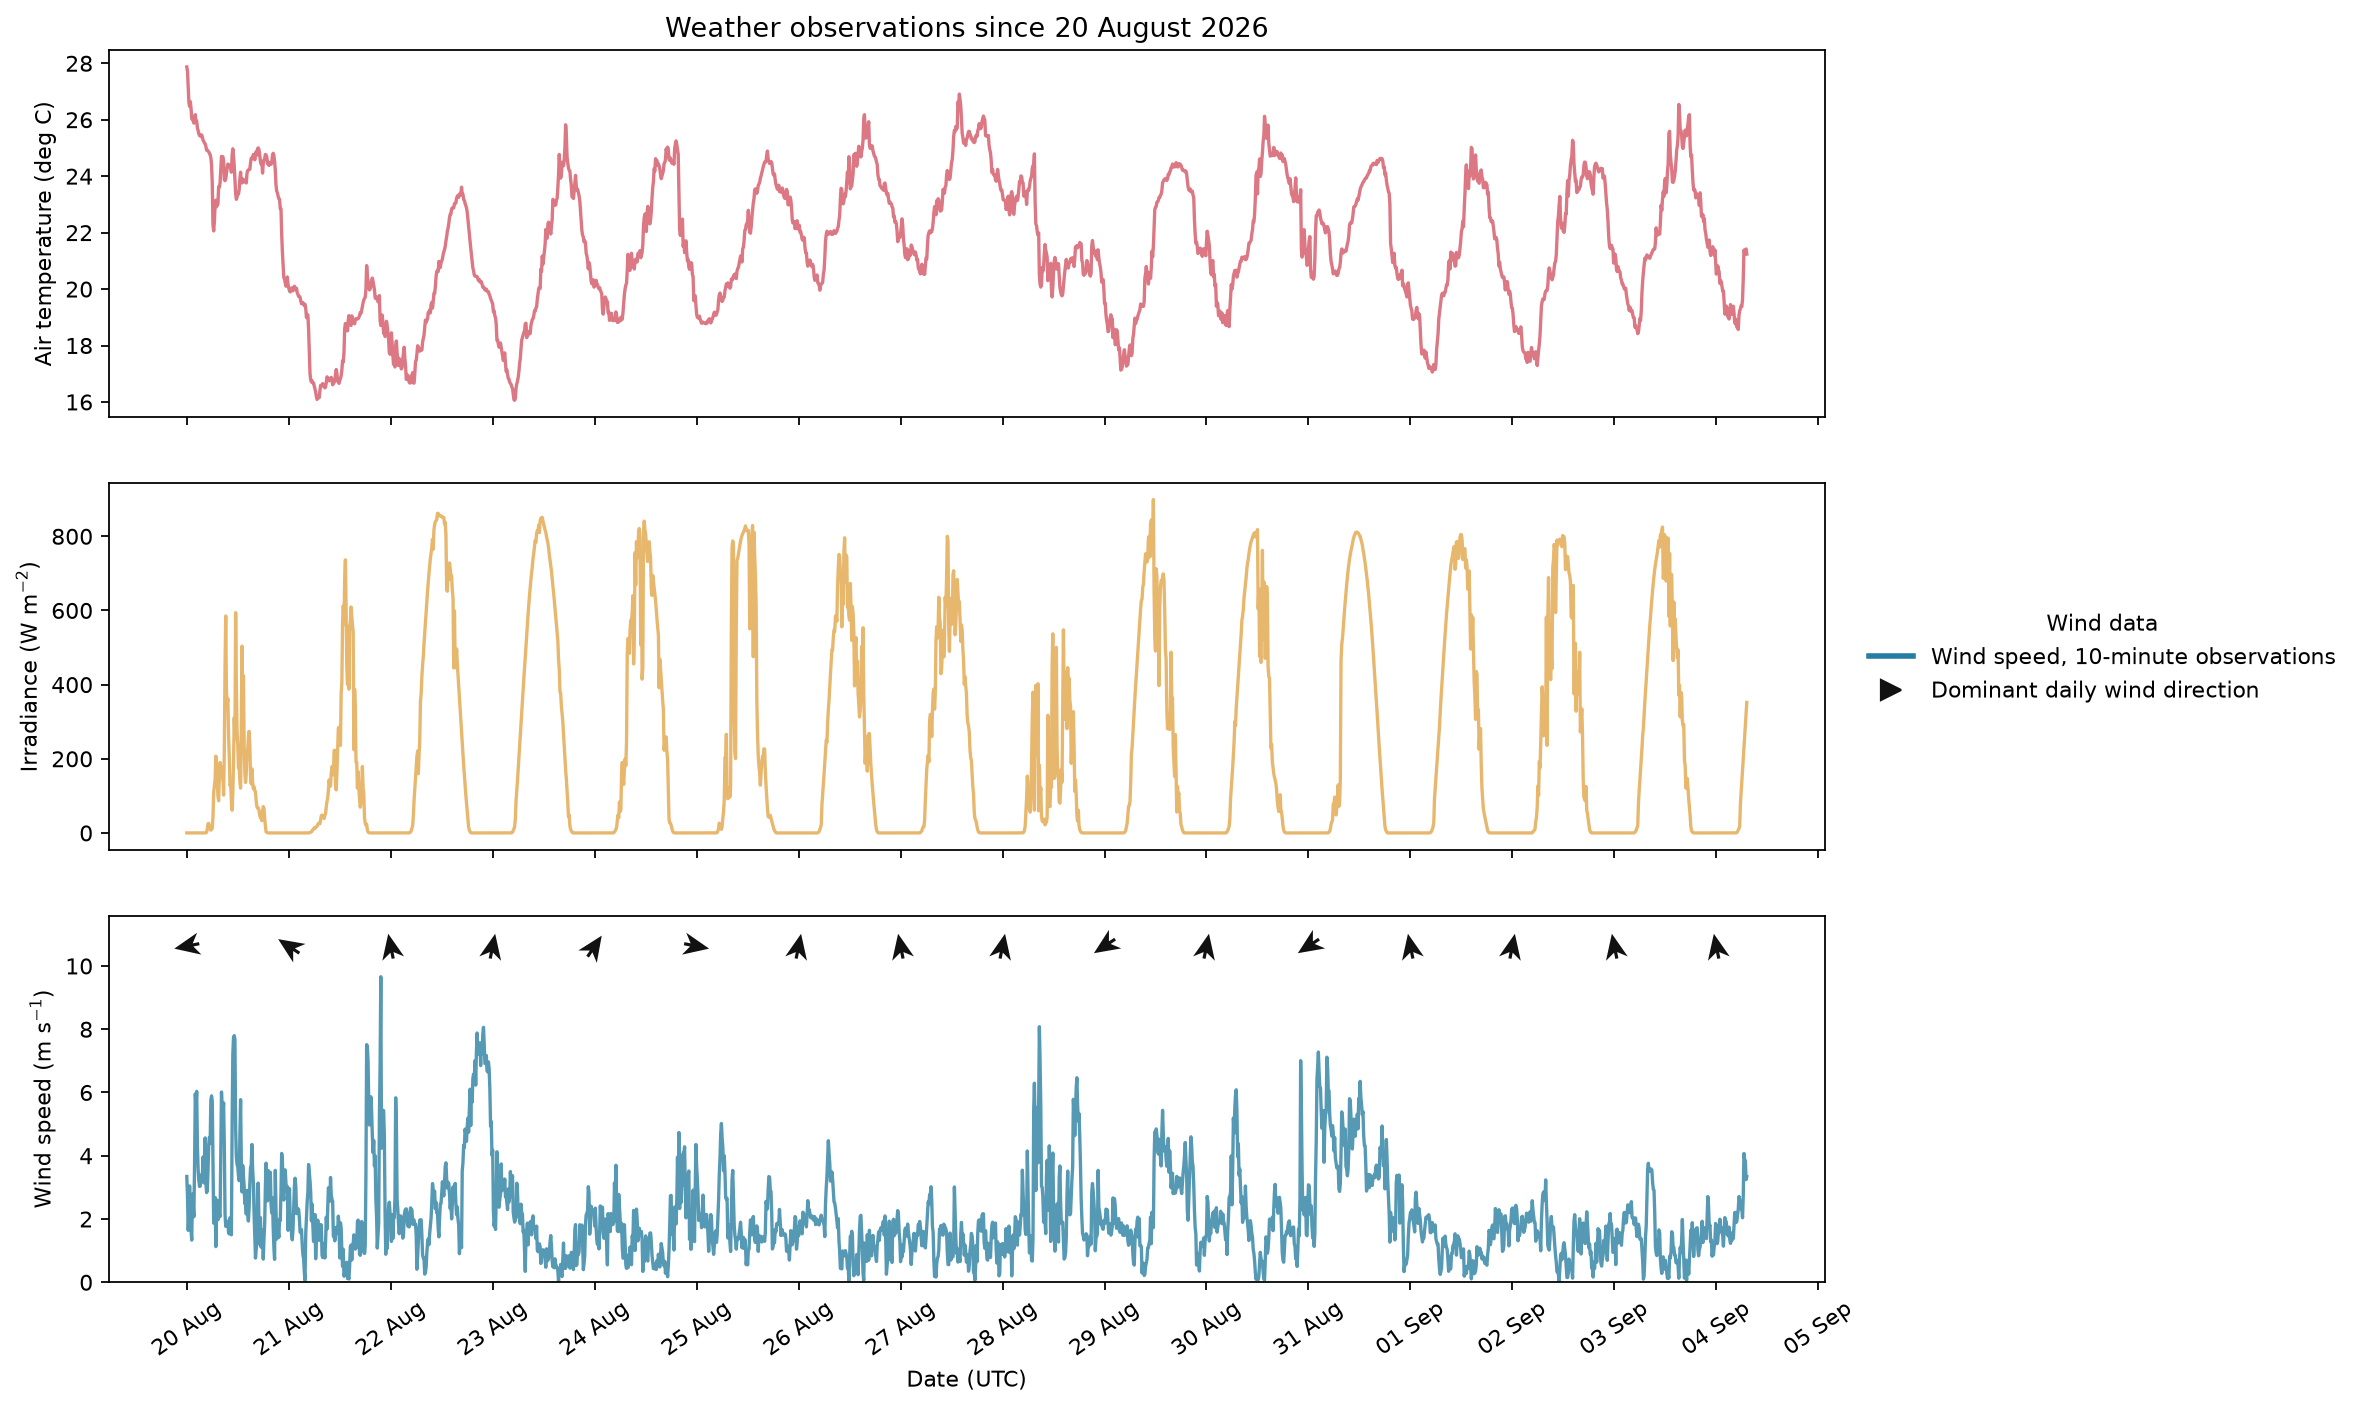

Weather observations plotted: 2,204
Weather days represented by direction arrows: 16
Saved: weather_since_2026_08_20.png


In [12]:
# Plot the quality-filtered observations at their native 10-minute resolution.
figure, axes = plt.subplots(3, 1, figsize=(15, 10), dpi=160, sharex=True)
figure.subplots_adjust(right=0.84, hspace=0.18)

axes[0].plot(weather["timestamp"], weather["air_temperature_c"], color="#d1495b", linewidth=1.5, alpha=0.75)
axes[0].set_ylabel("Air temperature (deg C)")
axes[0].set_title("Weather observations since 20 August 2026")

axes[1].plot(weather["timestamp"], weather["irradiance_w_m2"], color="#e09f3e", linewidth=1.5, alpha=0.75)
axes[1].set_ylabel("Irradiance (W m$^{-2}$)")

axes[2].plot(weather["timestamp"], weather["wind_speed_m_s"], color="#277da1", linewidth=1.5, alpha=0.78)
raw_wind_max = weather["wind_speed_m_s"].max()
arrow_y = raw_wind_max + max(0.5, raw_wind_max * 0.1)
arrow_dates = mdates.date2num(weather_daily["date"].dt.to_pydatetime())
arrow_radians = np.deg2rad(weather_daily["dominant_wind_direction_deg"])
# Use long, bold arrows in data coordinates so the daily direction is easy to see.
arrow_u = 0.25 * np.sin(arrow_radians)
arrow_v = 0.8 * np.cos(arrow_radians)
axes[2].quiver(arrow_dates, np.full(len(weather_daily), arrow_y), arrow_u, arrow_v, angles="xy", scale_units="xy", scale=1, color="#111111", width=0.006, headwidth=7, headlength=8, headaxislength=6, pivot="mid")
axes[2].set_ylim(0, arrow_y + max(0.5, raw_wind_max * 0.1))
axes[2].set_ylabel("Wind speed (m s$^{-1}$)")
axes[2].set_xlabel("Date (UTC)")

for axis in axes:
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axis.tick_params(axis="x", rotation=35)
legend_handles = [
    plt.Line2D([], [], color="#277da1", linewidth=2.5, label="Wind speed, 10-minute observations"),
    plt.Line2D([], [], color="#111111", marker=">", linestyle="None", markersize=9, label="Dominant daily wind direction"),
]
figure.legend(handles=legend_handles, frameon=False, loc="center left", bbox_to_anchor=(0.85, 0.5), title="Wind data")
figure.savefig(WEATHER_PNG, bbox_inches="tight")
plt.show()
print(f"Weather observations plotted: {len(weather):,}")
print(f"Weather days represented by direction arrows: {len(weather_daily):,}")
print(f"Saved: {WEATHER_PNG.name}")

## 1. Load and Filter CTD Profiles

Each NetCDF file is treated as one profile. The profile date is the median timestamp in the file, and only profiles strictly later than 15 August 2026 are retained.

In [13]:
REQUIRED_VARIABLES = {"time", "depth", "Temp", "Chl_A", "Cond", "depth_qual", "Temp_qual", "Chl_A_qual", "Cond_qual"}
nc_paths = sorted(DATA_DIR.glob("*.nc"))
assert nc_paths, f"No CTD NetCDF files found in {DATA_DIR}"

profiles = []
for path in nc_paths:
    with Dataset(path) as source:
        missing = REQUIRED_VARIABLES.difference(source.variables)
        assert not missing, f"{path.name} is missing {sorted(missing)}"
        time_var = source.variables["time"]
        timestamps = pd.to_datetime(num2date(time_var[:], time_var.units, only_use_cftime_datetimes=False), utc=True)
        timestamps = timestamps.sort_values()
        profile_date = timestamps[len(timestamps) // 2]
        if profile_date < CUTOFF:
            continue
        depth_m = np.asarray(source.variables["depth"][:], dtype=float)
        temperature_c = np.asarray(source.variables["Temp"][:], dtype=float)
        conductivity_ms_cm = np.asarray(source.variables["Cond"][:], dtype=float)
        profiles.append({
            "file": path.name,
            "date": profile_date,
            "depth_m": depth_m,
            "temperature_c": temperature_c,
            "chlorophyll_ug_l": np.asarray(source.variables["Chl_A"][:], dtype=float),
            "conductivity_ms_cm": conductivity_ms_cm,
            "conductivity_normalized_ms_cm": conductivity_ms_cm / (1 + CONDUCTIVITY_ALPHA_PER_C * (temperature_c - REFERENCE_TEMPERATURE_C)),
            "depth_qual": np.asarray(source.variables["depth_qual"][:]),
            "temperature_qual": np.asarray(source.variables["Temp_qual"][:]),
            "chlorophyll_qual": np.asarray(source.variables["Chl_A_qual"][:]),
            "conductivity_qual": np.asarray(source.variables["Cond_qual"][:]),
        })

assert profiles, f"No profiles on or after {CUTOFF.date()}"
profiles = sorted(profiles, key=lambda profile: profile["date"])
print(f"All CTD files: {len(nc_paths):,}")
print(f"Profiles on or after cutoff: {len(profiles):,}")
print(f"Date range: {profiles[0]['date']} to {profiles[-1]['date']}")

All CTD files: 484
Profiles on or after cutoff: 9
Date range: 2026-08-24 13:11:16+00:00 to 2026-09-02 09:04:20+00:00


## 2. Plot Temperature and Chlorophyll-a Profiles

Conductivity is normalized to 25 deg C using simultaneous water temperature and alpha = 0.02 per deg C. The same date color scale is shared by all panels. Depth increases downward, so the vertical axis is inverted.

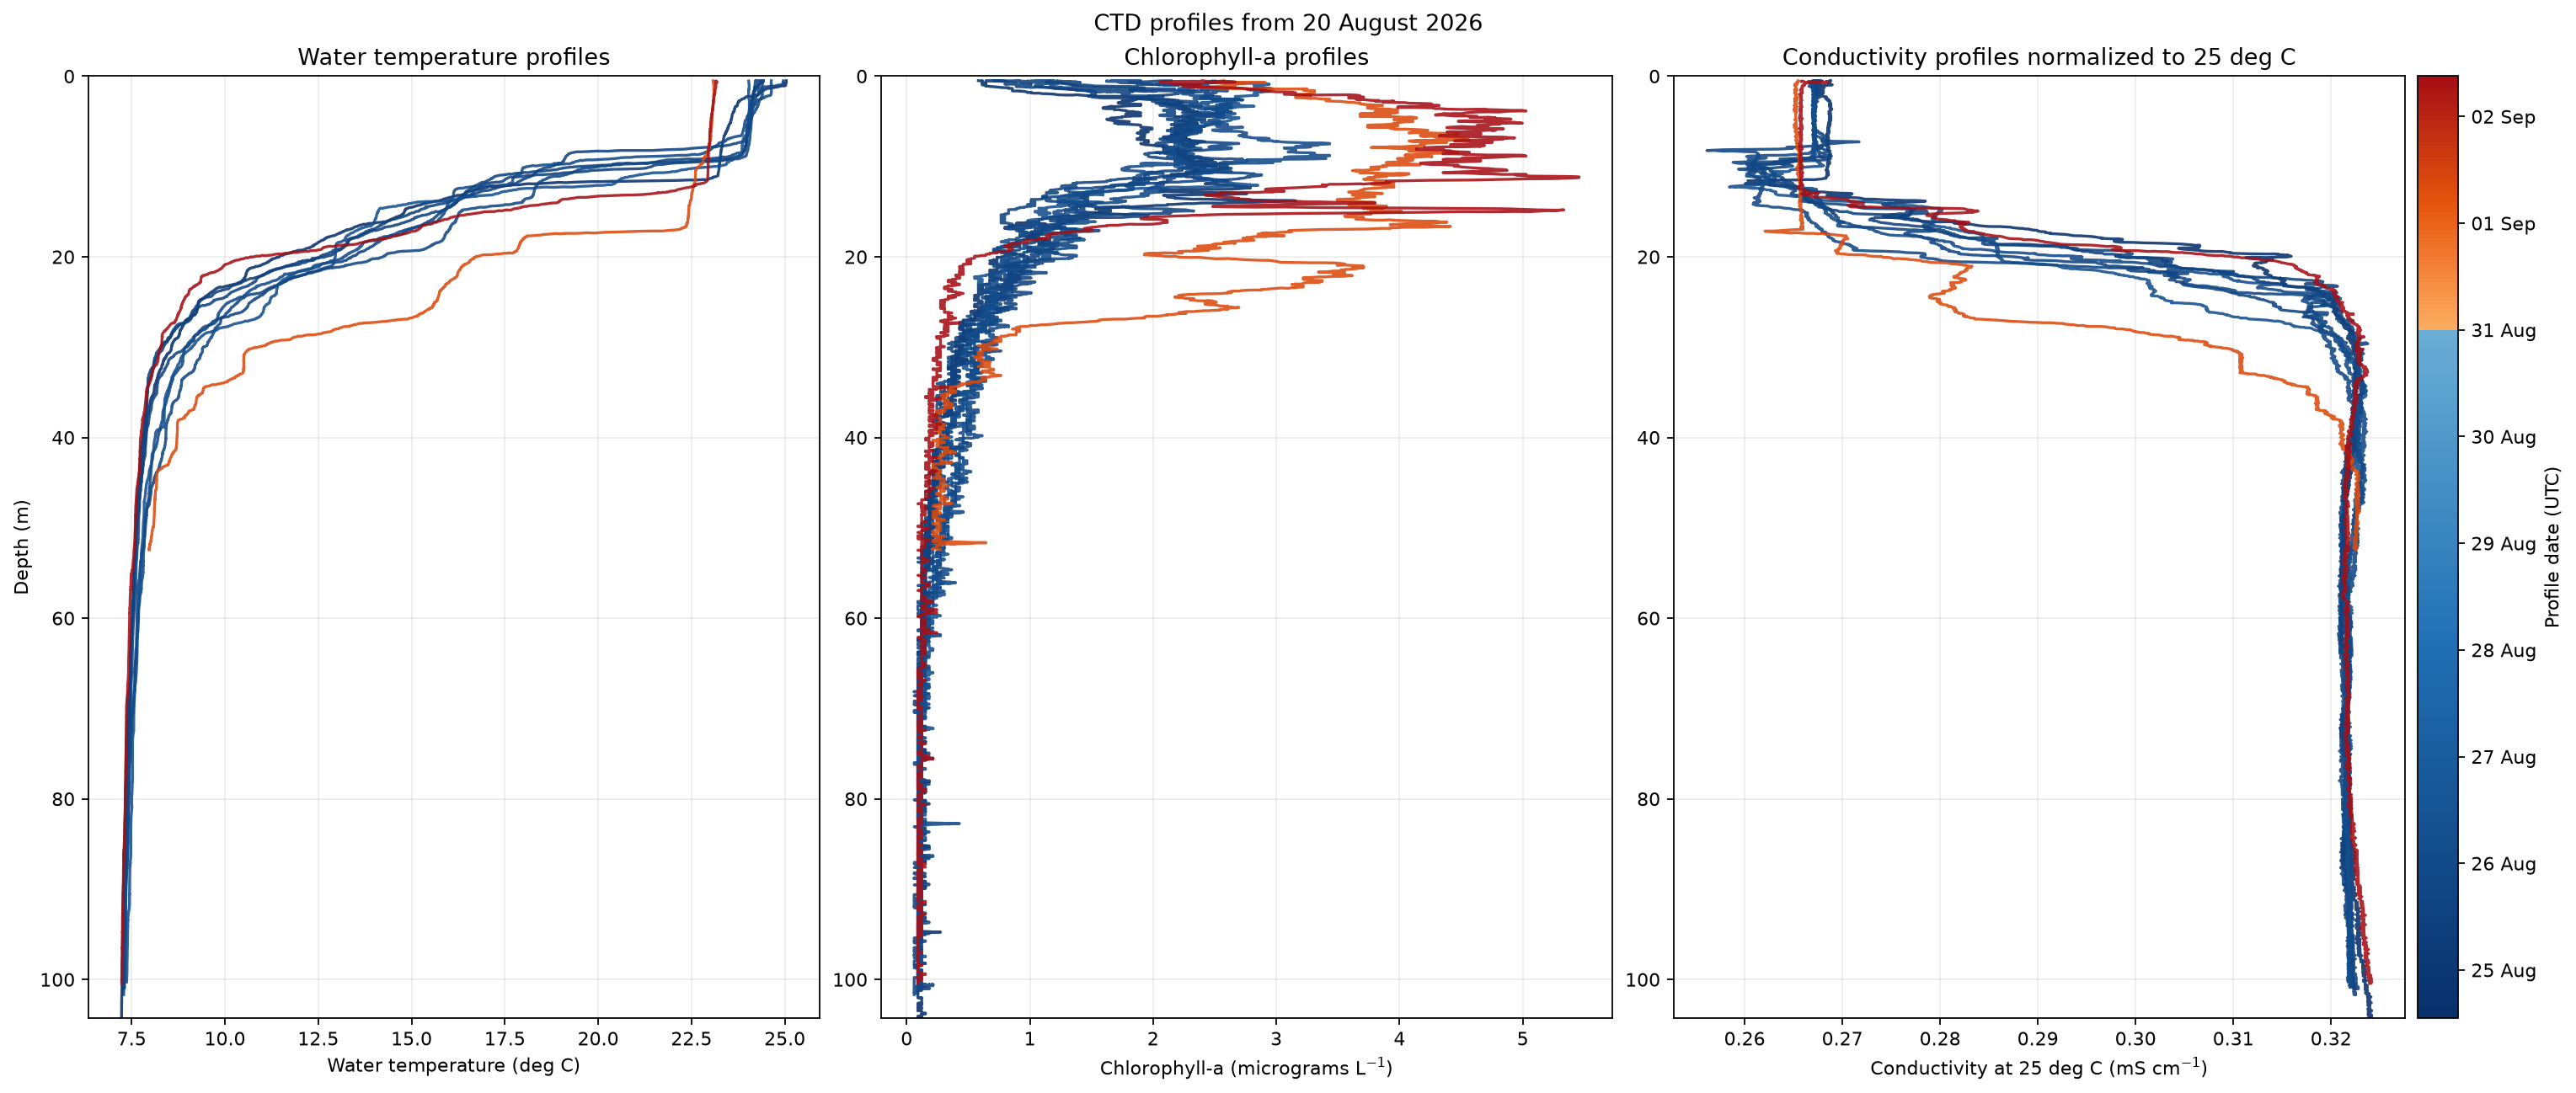

Saved: ctd_temperature_chlorophyll_profiles_from_2026_08_20.png


In [19]:
date_numbers = mdates.date2num([profile["date"].to_pydatetime() for profile in profiles])
DATE_SPLIT = pd.Timestamp("2026-08-31", tz="UTC")
split_number = mdates.date2num(DATE_SPLIT.to_pydatetime())
normalizer = Normalize(vmin=date_numbers.min(), vmax=date_numbers.max())
split_position = np.clip(normalizer(split_number), 0.01, 0.99)

# Use sharp, high-contrast gradients: blue before 31 August and orange-red afterward.
color_map = LinearSegmentedColormap.from_list(
    "sharp_date_period_gradient",
    [
        (0.0, "#08306b"),
        (split_position * 0.55, "#2171b5"),
        (split_position, "#6baed6"),
        (min(split_position + 0.001, 0.999), "#fdae61"),
        (split_position + (1 - split_position) * 0.5, "#e6550d"),
        (1.0, "#a50f15"),
    ],
)

# Normalize conductivity to 25 deg C using simultaneous temperature.
for profile in profiles:
    profile["conductivity_normalized_ms_cm"] = profile["conductivity_ms_cm"] / (1 + CONDUCTIVITY_ALPHA_PER_C * (profile["temperature_c"] - REFERENCE_TEMPERATURE_C))

# Reserve a fourth column for the date color scale outside the three plots.
figure = plt.figure(figsize=(19, 8), dpi=160, constrained_layout=True)
grid = figure.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.055])
axes = [figure.add_subplot(grid[0, 0]), figure.add_subplot(grid[0, 1]), figure.add_subplot(grid[0, 2])]
colorbar_axis = figure.add_subplot(grid[0, 3])
axes[1].sharey(axes[0])
axes[2].sharey(axes[0])

for profile, date_number in zip(profiles, date_numbers):
    color = color_map(normalizer(date_number))
    common_mask = np.isfinite(profile["depth_m"])
    temperature_mask = common_mask & np.isfinite(profile["temperature_c"]) & (profile["depth_qual"] == 0) & (profile["temperature_qual"] == 0)
    chlorophyll_mask = common_mask & np.isfinite(profile["chlorophyll_ug_l"]) & (profile["depth_qual"] == 0) & (profile["chlorophyll_qual"] == 0)
    conductivity_mask = common_mask & np.isfinite(profile["conductivity_normalized_ms_cm"]) & np.isfinite(profile["temperature_c"]) & (profile["depth_qual"] == 0) & (profile["temperature_qual"] == 0) & (profile["conductivity_qual"] == 0)
    axes[0].plot(profile["temperature_c"][temperature_mask], profile["depth_m"][temperature_mask], color=color, linewidth=1.5, alpha=0.88)
    axes[1].plot(profile["chlorophyll_ug_l"][chlorophyll_mask], profile["depth_m"][chlorophyll_mask], color=color, linewidth=1.5, alpha=0.88)
    axes[2].plot(profile["conductivity_normalized_ms_cm"][conductivity_mask], profile["depth_m"][conductivity_mask], color=color, linewidth=1.5, alpha=0.88)

axes[0].set_title("Water temperature profiles")
axes[0].set_xlabel("Water temperature (deg C)")
axes[0].set_ylabel("Depth (m)")
axes[1].set_title("Chlorophyll-a profiles")
axes[1].set_xlabel("Chlorophyll-a (micrograms L$^{-1}$)")
axes[2].set_title("Conductivity profiles normalized to 25 deg C")
axes[2].set_xlabel("Conductivity at 25 deg C (mS cm$^{-1}$)")
max_depth = max(np.nanmax(profile["depth_m"]) for profile in profiles)
for axis in axes:
    axis.set_ylim(max_depth, 0)
    axis.grid(True, alpha=0.22)

scalar_map = ScalarMappable(norm=normalizer, cmap=color_map)
scalar_map.set_array([])
colorbar = figure.colorbar(scalar_map, cax=colorbar_axis)
colorbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
colorbar.set_label("Profile date (UTC)")
figure.suptitle(f"CTD profiles from {CUTOFF.strftime('%d %B %Y')}")
figure.savefig(OUTPUT_PNG, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_PNG.name}")